# Data Cleaning Notebook

## Objectives

*   Evaluate missing data
*   Clean data

## Inputs

* outputs/datasets/collection/HousePricing.csv


## Conclusions

  Data Cleaning Pipeline

  * Median Imputer - `['2ndFlrSF', 'BedroomAbvGr', 'GarageYrBlt', 'LotFrontage', 'MasVnrArea']` 

  * Categorical Imputer - `['BsmtFinType1','GarageFinish']`. 

  * Drop - `['EnclosedPorch', 'WoodDeckSF']` 



---


## Change working directory

We need to change the working directory from its current folder to its parent folder
* We access the current directory with os.getcwd()

In [1]:
import os
current_dir = os.getcwd()
current_dir

'/Users/rimanfarhood/development/pa/HeritageHousePrediction/jupyter_notebooks'

We want to make the parent of the current directory the new current directory
* os.path.dirname() gets the parent directory
* os.chir() defines the new current directory

In [2]:
os.chdir(os.path.dirname(current_dir))
print("You set a new current directory")

You set a new current directory


Confirm the new current directory

In [3]:
current_dir = os.getcwd()
current_dir

'/Users/rimanfarhood/development/pa/HeritageHousePrediction'

---

In [4]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import ppscore as pps
import warnings
%matplotlib inline

warnings.filterwarnings('ignore')

from sklearn.pipeline import Pipeline
# from ydata_profiling import ProfileReport
from feature_engine.imputation import CategoricalImputer
from feature_engine.imputation import MeanMedianImputer
from feature_engine.selection import DropFeatures


# Load Collected data

In [5]:
pd.set_option('display.max_rows', None)
pd.set_option('display.max_columns', None)

In [6]:
df = pd.read_csv("outputs/datasets/collection/HousePricing.csv")
df.head(20)

,1stFlrSF,2ndFlrSF,BedroomAbvGr,BsmtExposure,BsmtFinSF1,BsmtFinType1,BsmtUnfSF,EnclosedPorch,GarageArea,GarageFinish,GarageYrBlt,GrLivArea,KitchenQual,LotArea,LotFrontage,MasVnrArea,OpenPorchSF,OverallCond,OverallQual,TotalBsmtSF,WoodDeckSF,YearBuilt,YearRemodAdd,SalePrice
0,856,854.0,3.0,No,706,GLQ,150,0.0,548,RFn,2003.0,1710,Gd,8450,65.0,196.0,61,5,7,856,0.0,2003,2003,208500
1,1262,0.0,3.0,Gd,978,ALQ,284,NaN,460,RFn,1976.0,1262,TA,9600,80.0,0.0,0,8,6,1262,NaN,1976,1976,181500
2,920,866.0,3.0,Mn,486,GLQ,434,0.0,608,RFn,2001.0,1786,Gd,11250,68.0,162.0,42,5,7,920,NaN,2001,2002,223500
3,961,NaN,NaN,No,216,ALQ,540,NaN,642,Unf,1998.0,1717,Gd,9550,60.0,0.0,35,5,7,756,NaN,1915,1970,140000
4,1145,NaN,4.0,Av,655,GLQ,490,0.0,836,RFn,2000.0,2198,Gd,14260,84.0,350.0,84,5,8,1145,NaN,2000,2000,250000
5,796,566.0,1.0,No,732,GLQ,64,NaN,480,Unf,1993.0,1362,TA,14115,85.0,0.0,30,5,5,796,NaN,1993,1995,143000
6,1694,0.0,3.0,Av,1369,GLQ,317,NaN,636,RFn,2004.0,1694,Gd,10084,75.0,186.0,57,5,8,1686,NaN,2004,2005,307000
7,1107,983.0,3.0,Mn,859,ALQ,216,NaN,484,NaN,1973.0,2090,TA,10382,NaN,240.0,204,6,7,1107,NaN,1973,1973,200000
8,1022,752.0,2.0,No,0,Unf,952,NaN,468,Unf,1931.0,1774,TA,6120,51.0,0.0,0,5,7,952,NaN,1931,1950,129900
9,1077,0.0,2.0,No,851,GLQ,140,NaN,205,RFn,1939.0,1077,TA,7420,50.0,0.0,4,6,5,991,NaN,1939,1950,118000


# Data Exploration

In Data Cleaning you are interested to check the distribution and shape of a variable with missing data.

In [7]:
vars_with_missing_data = df.columns[df.isna().sum() > 0].to_list()
vars_with_missing_data

['2ndFlrSF',
 'BedroomAbvGr',
 'BsmtExposure',
 'BsmtFinType1',
 'EnclosedPorch',
 'GarageFinish',
 'GarageYrBlt',
 'LotFrontage',
 'MasVnrArea',
 'WoodDeckSF']

In [8]:
# from ydata_profiling import ProfileReport
# if vars_with_missing_data:
#     profile = ProfileReport(df=df[vars_with_missing_data], minimal=True)
#     profile.to_notebook_iframe()
# else:
#     print("There are no variables with missing data")


# Data Cleaning

## Assessing Missing Data Levels

* Custom function to display missing data levels in a DataFrame, it shows the absolute levels, relative levels and data type.

In [9]:
def EvaluateMissingData(df):
    missing_data_absolute = df.isnull().sum()
    missing_data_percentage = round(missing_data_absolute/len(df)*100, 2)
    df_missing_data = (pd.DataFrame(
                            data={"RowsWithMissingData": missing_data_absolute,
                                   "PercentageOfDataset": missing_data_percentage,
                                   "DataType": df.dtypes}
                                    )
                          .sort_values(by=['PercentageOfDataset'], ascending=False)
                          .query("PercentageOfDataset > 0")
                          )

    return df_missing_data


Check missing data levels for the collected dataset.

In [10]:
EvaluateMissingData(df)

,RowsWithMissingData,PercentageOfDataset,DataType
EnclosedPorch,1324,90.68,float64
WoodDeckSF,1305,89.38,float64
LotFrontage,259,17.74,float64
GarageFinish,235,16.10,object
BsmtFinType1,145,9.93,object
BedroomAbvGr,99,6.78,float64
2ndFlrSF,86,5.89,float64
GarageYrBlt,81,5.55,float64
BsmtExposure,38,2.60,object
MasVnrArea,8,0.55,float64


## Dealing with Missing Data

* This is a custom function from the 'Feature Engineering Lesson Notebook unit 9'

In [11]:
def DataCleaningEffect(df_original,df_cleaned,variables_applied_with_method):

  flag_count=1 # Indicate plot number
  
  # distinguish between numerical and categorical variables
  categorical_variables = df_original.select_dtypes(exclude=['number']).columns 

  # scan over variables, 
    # first on variables that you applied the method
    # if the variable is a numerical plot, a histogram if categorical plot a barplot
  for set_of_variables in [variables_applied_with_method]:
    print("\n=====================================================================================")
    print(f"* Distribution Effect Analysis After Data Cleaning Method in the following variables:")
    print(f"{set_of_variables} \n\n")
  

    for var in set_of_variables:
      if var in categorical_variables:  # it is categorical variable: barplot
        
        df1 = pd.DataFrame({"Type":"Original","Value":df_original[var]})
        df2 = pd.DataFrame({"Type":"Cleaned","Value":df_cleaned[var]})
        dfAux = pd.concat([df1, df2], axis=0).reset_index(drop=True)
        fig , axes = plt.subplots(figsize=(15, 5))
        sns.countplot(hue='Type', data=dfAux, x="Value",palette=['#432371',"#FAAE7B"])
        axes.set(title=f"Distribution Plot {flag_count}: {var}")
        plt.xticks(rotation=90)
        plt.legend() 

      else: # it is numerical variable: histogram

        fig , axes = plt.subplots(figsize=(10, 5))
        sns.histplot(data=df_original, x=var, color="#432371", label='Original', kde=True,element="step", ax=axes)
        sns.histplot(data=df_cleaned, x=var, color="#FAAE7B", label='Cleaned', kde=True,element="step", ax=axes)
        axes.set(title=f"Distribution Plot {flag_count}: {var}")
        plt.legend() 

      plt.show()
      flag_count+= 1

### Data Cleaning Summary

Potential Cleaning approaches 

* Median Imputer - `['2ndFlrSF', 'BedroomAbvGr', 'GarageYrBlt', 'LotFrontage', 'MasVnrArea']` since the distribution isn't bell shape curved

* Categorical Imputer - `['BsmtFinType1','GarageFinish']`. 

* Drop - `['EnclosedPorch', 'WoodDeckSF']` Have a high percentage of missing values, in real life not all houses do have a porch nor a wood deck area but since we don't actually know if they don't have a porch or wood deck or that there just isn't any record of it. There for the decision to drop. 



### Split Train and Test Set

In [12]:
from sklearn.model_selection import train_test_split
TrainSet, TestSet, _, __ = train_test_split(
                                        df,
                                        df['SalePrice'],
                                        test_size=0.2,
                                        random_state=0)

print(f"TrainSet shape: {TrainSet.shape} \nTestSet shape: {TestSet.shape}")

TrainSet shape: (1168, 24) 
TestSet shape: (292, 24)


In [13]:
df_missing_data = EvaluateMissingData(TrainSet)
print(f"* There are {df_missing_data.shape[0]} variables with missing data \n")
df_missing_data

* There are 10 variables with missing data 



,RowsWithMissingData,PercentageOfDataset,DataType
EnclosedPorch,1056,90.41,float64
WoodDeckSF,1034,88.53,float64
LotFrontage,212,18.15,float64
GarageFinish,184,15.75,object
BsmtFinType1,114,9.76,object
BedroomAbvGr,80,6.85,float64
2ndFlrSF,60,5.14,float64
GarageYrBlt,58,4.97,float64
BsmtExposure,28,2.40,object
MasVnrArea,6,0.51,float64


In [14]:
median_imp =  ['2ndFlrSF', 'BedroomAbvGr', 'GarageYrBlt', 'LotFrontage', 'MasVnrArea']
drop = ['EnclosedPorch', 'WoodDeckSF',]
missing_cat = ['BsmtFinType1','GarageFinish', 'BsmtExposure']

---

### MeanMedianImputer

**Impute missing values with median** 

Since the missing data levels isn't so high and the distribution isn't bell shape curved I'll fill the missing values with median imputation
- `['2ndFlrSF', 'BedroomAbvGr', 'GarageYrBlt', 'LotFrontage', 'MasVnrArea']`


* Distribution Effect Analysis After Data Cleaning Method in the following variables:
['2ndFlrSF', 'BedroomAbvGr', 'GarageYrBlt', 'LotFrontage', 'MasVnrArea'] 




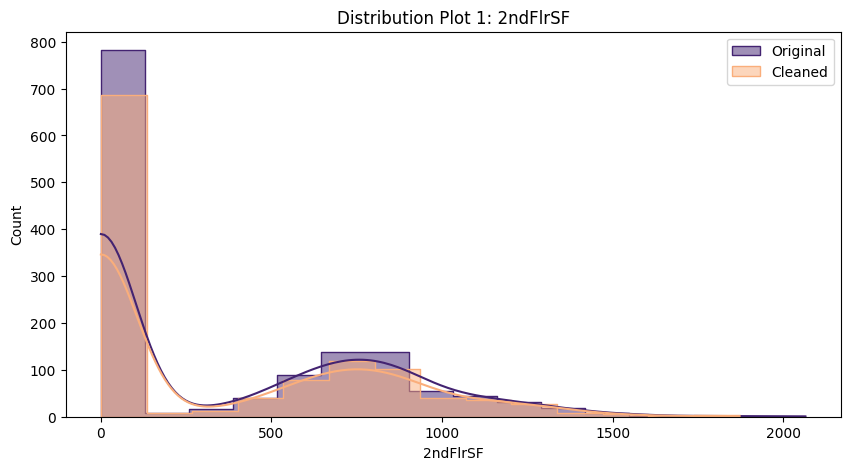

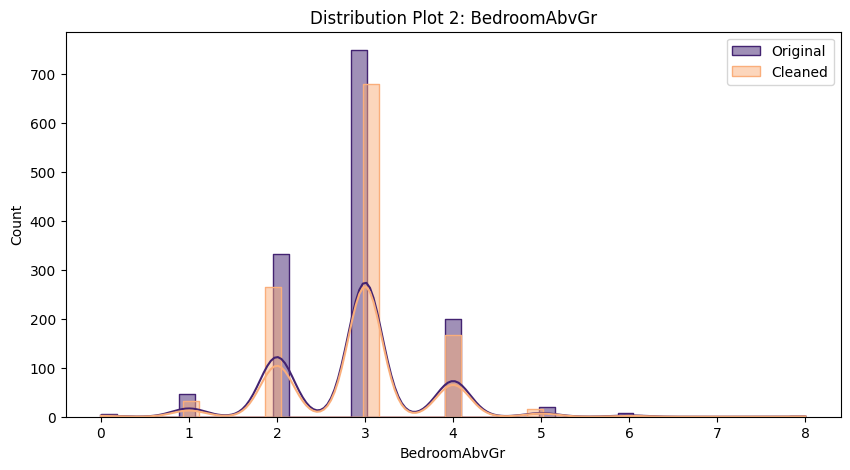

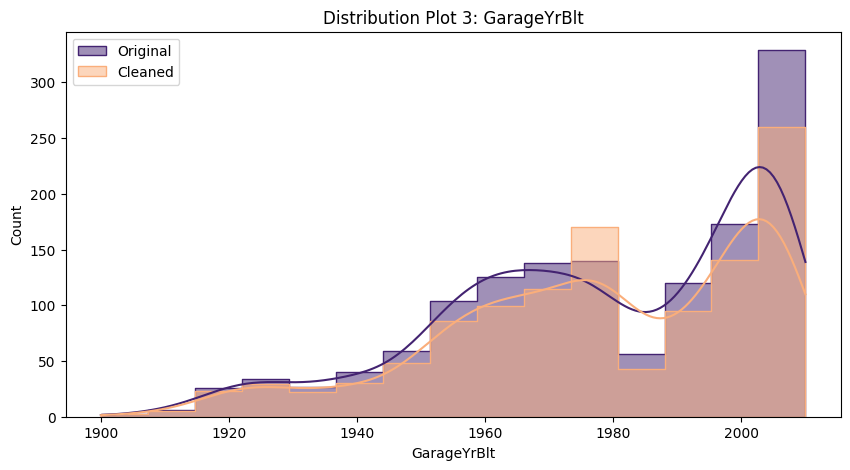

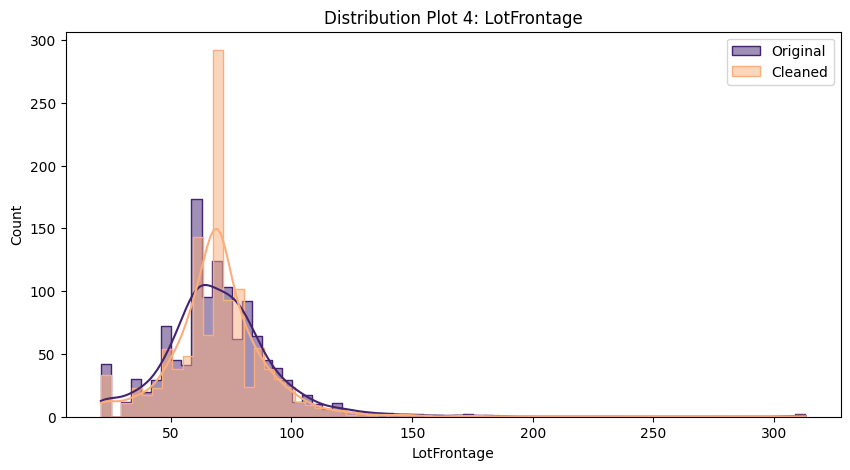

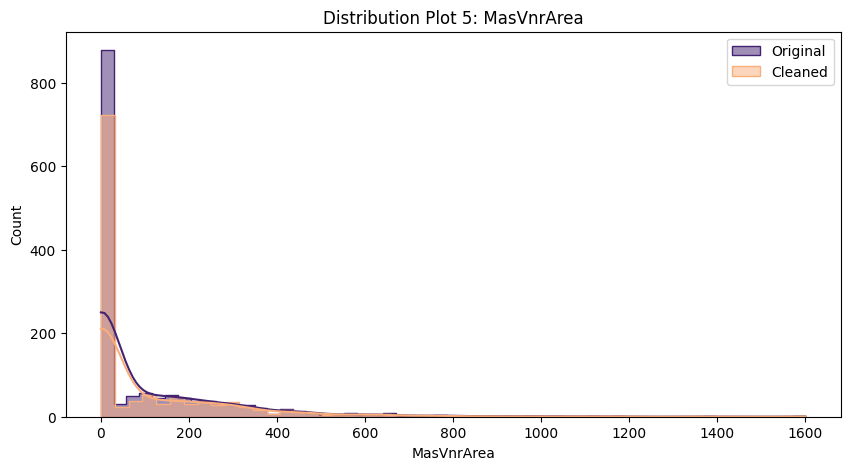

In [15]:
variables_method = median_imp
imputer = MeanMedianImputer(imputation_method='median', variables=variables_method)
df_method = imputer.fit_transform(TrainSet)

DataCleaningEffect(df_original=df,
                   df_cleaned=df_method,
                   variables_applied_with_method=variables_method)

The imputation hasn't had a major affect on the distribution just a little bit as expected.

### Categorical Imputation

**Imputation method 'missing'**
- `['BsmtFinType1','GarageFinish']`


* Distribution Effect Analysis After Data Cleaning Method in the following variables:
['BsmtFinType1', 'GarageFinish', 'BsmtExposure'] 




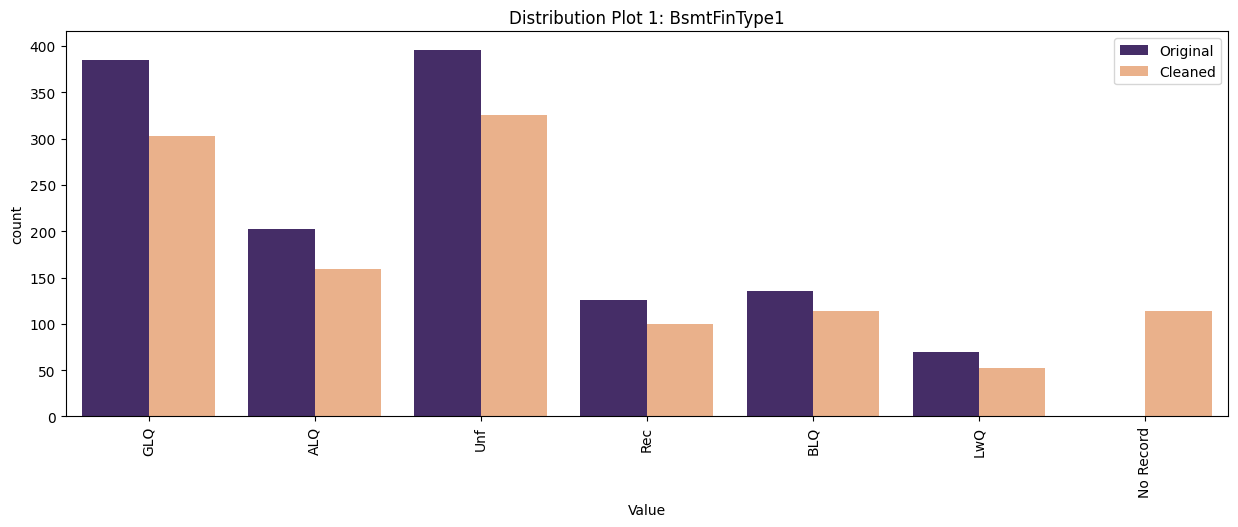

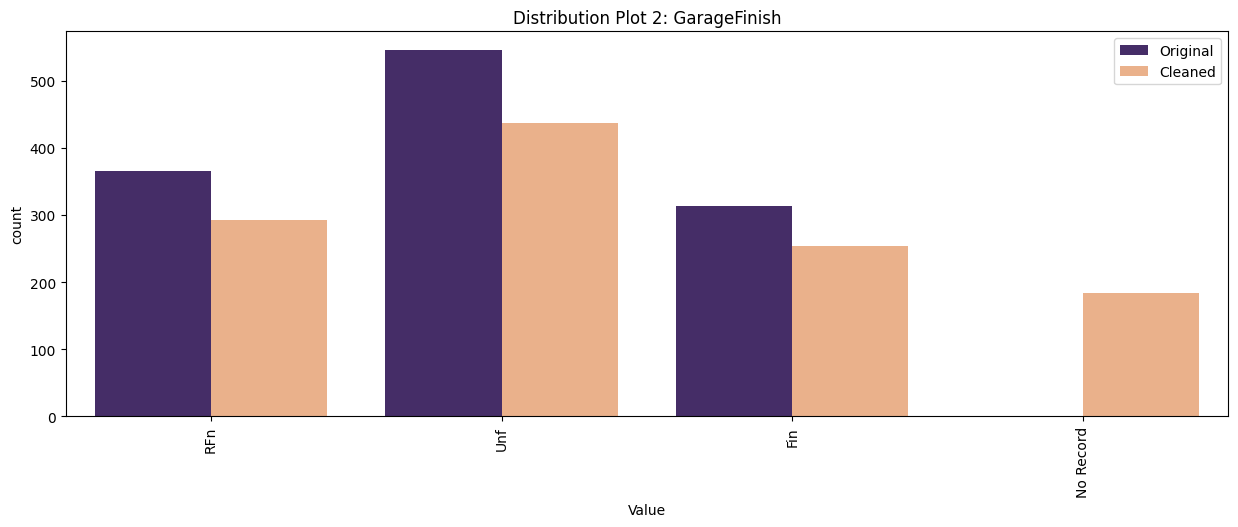

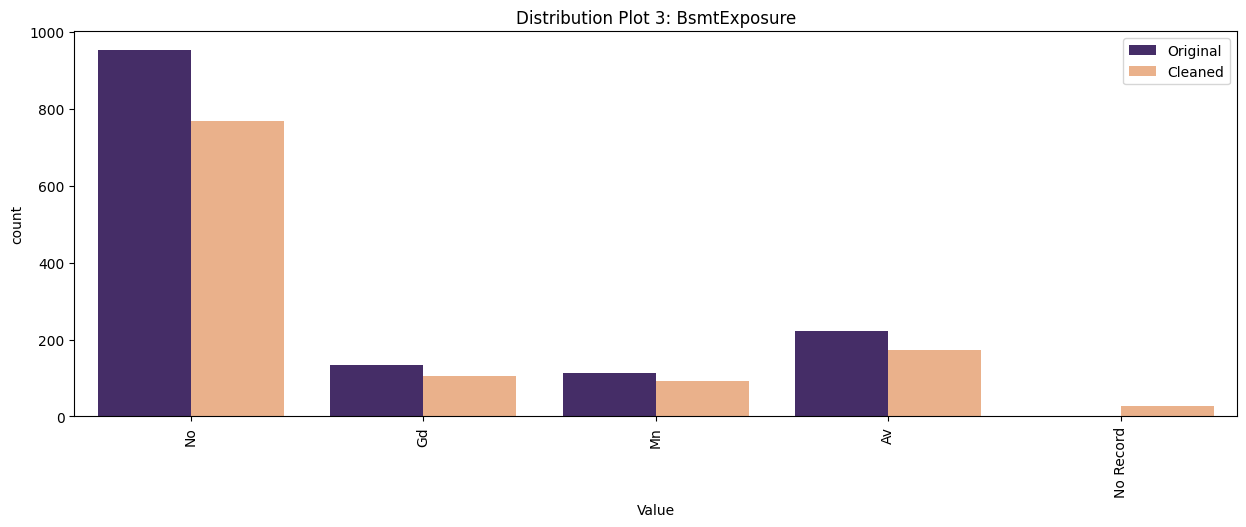

In [16]:
variables_method = missing_cat
imputer = CategoricalImputer(imputation_method='missing', fill_value='No Record', variables=variables_method)
df_method =imputer.fit_transform(TrainSet)

DataCleaningEffect(df_original=df,
                   df_cleaned=df_method,
                   variables_applied_with_method=variables_method)

The distribution has been impacted as thought but for now i will apply this changes to prepare the model for data similar to the real-time data, 
from my research real estate house data is usually right skewed towards the higher prices

* Step 5: If you are satisfied, apply the transformation to your data.

In [17]:
pipeline = Pipeline([
      ('Median', MeanMedianImputer(imputation_method='median', 
                                   variables=['2ndFlrSF', 'BedroomAbvGr', 'GarageYrBlt', 
                                              'LotFrontage', 'MasVnrArea']
                                              )),
      ('CategoricalImputer', CategoricalImputer(imputation_method='missing', 
                                                fill_value='No Record', 
                                                variables=['BsmtFinType1','GarageFinish', 'BsmtExposure']
                                                )),
      ('Drop', DropFeatures(features_to_drop=['EnclosedPorch', 'WoodDeckSF']))
])
pipeline

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('Median', ...), ('CategoricalImputer', ...), ...]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,imputation_method,'median'
,variables,"['2ndFlrSF', 'BedroomAbvGr', ...]"
,imputation_method,'missing'
,fill_value,'No Record'
,variables,"['BsmtFinType1', 'GarageFinish', ...]"
,return_object,False
,ignore_format,False


### Data Cleaning Pipeline

### Fit pipeline

In [18]:
pipeline.fit(TrainSet)

TrainSet, TestSet = pipeline.transform(TrainSet) , pipeline.transform(TestSet)

I'll Also apply this step to the entire dataset and save for use in the streamlit dashboard. So client can inspect the dataset as used.

In [19]:
pipeline.fit(df)

df = pipeline.transform(df)

**Evaluation**

In [20]:
EvaluateMissingData(TrainSet)

,RowsWithMissingData,PercentageOfDataset,DataType


In [21]:
EvaluateMissingData(TestSet)

,RowsWithMissingData,PercentageOfDataset,DataType


In [22]:
EvaluateMissingData(df)

,RowsWithMissingData,PercentageOfDataset,DataType


This steps will be added to the ML pipeline

### Push cleaned data to Repo

In [23]:
try:
  # create here your folder
  os.makedirs(name='outputs/datasets/collection/cleaned')
except Exception as e:
  print(e)


[Errno 17] File exists: 'outputs/datasets/collection/cleaned'


### Dataset

In [24]:
df.to_csv("outputs/datasets/collection/cleaned/CleanedHousePricing.csv", index=False)

### Train Set

In [25]:
TrainSet.to_csv("outputs/datasets/collection/cleaned/TrainSet.csv", index=False)

### Test Set 

In [26]:
TestSet.to_csv("outputs/datasets/collection/cleaned/TestSet.csv", index=False)